# Encoding Strategy Comparison

## Research question

**Overall question:** Do age and transportation habits predict communication apprehension?

**Individual subquestion:** Which transportation encoding strategy—composite or dummy encoding—produces better predictive performance?

This notebook:

1. Loads the cleaned and merged survey dataset.
2. Scores communication apprehension.
3. Creates composite and dummy transportation encodings.
4. Uses identical repeated 10-fold cross-validation folds.
5. Compares model performance using R², RMSE, and MAE.
6. Produces tables and Seaborn visualizations summarizing the results.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold

sns.set_theme()

DATA_FILE = Path("/Users/jakevanvleet/Projects/QualtricsDemo/data/DATACOMBINED.csv")
RESULTS_DIR = Path("/Users/jakevanvleet/Projects/groupproject/data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

OUTCOME = "comm_apprehension_score"

N_SPLITS = 10
N_REPEATS = 30
RANDOM_STATE = 755

print("Packages loaded.")

Packages loaded.


## 1. Load the cleaned and merged survey data

The original survey responses were collected in separate datasets. Before modeling, the datasets were cleaned, merged using the respondent identifier, and checked for duplicate or unmatched records. The resulting merged dataset was saved as `DATACOMBINED.csv`, which is used throughout the remainder of this notebook.

Loading the merged dataset rather than repeating the cleaning process keeps this notebook focused on the encoding comparison while documenting the preprocessing completed before analysis.


In [2]:
raw = pd.read_csv(DATA_FILE)

print(f"Rows: {raw.shape[0]}")
print(f"Columns: {raw.shape[1]}")

raw.head()

Rows: 252
Columns: 38


,Submission id,Participant id,Started at,Completed at,Time taken,Age,Total approvals,Sex,Country of residence,Student status,...,Q17,Q18,Q26,Q27,Q28,Q29,Q20,Q21,Q18.1,Q19
0,41af60010ed5b14f23564789e5a0a0c334bd7fbdf3392f...,01ed97565030e4d13eba2ecba6f408ba9b1d77f47fa2cc...,2026.0,2026.0,330.0,35.0,700+,Male,United Kingdom,No,...,Strongly agree,Strongly disagree,4-8 days a month,1-2 rides in a typical day,2-4 days a month,1-2 rides in a typical day,Yes,Yes,I would say just treat everyone the same. Try ...,"I think it is probably by train, just because ..."
1,0e38dcec47f7fd15361615c4d505bd924d727f7434e4fe...,0249e61e3a173da6ac2e5417f91dd474d39bec678466a1...,2026.0,2026.0,335.0,30.0,700+,Male,United States,No,...,Somewhat disagree,Neither agree nor disagree,Never,1-2 rides in a typical day,Never,1-2 rides in a typical day,Yes,Yes,"I get it, but the worst-case scenario isn't th...",I like to drive. I usually have a mental plan ...
2,55706e705f6f923f37c79aa9fc4b7d0aa19ab8ee99fc7f...,0424a1fe863ac20a26a5fb9a66f0bb9528170412fbca70...,2026.0,2026.0,472.0,26.0,700+,Male,United States,No,...,Somewhat agree,Somewhat disagree,8 or more days a month,1-2 rides in a typical day,Never,1-2 rides in a typical day,No,No,Identify what it is that is causing the nervou...,I typically prefer walking as I no long have a...
3,adddca692da84fcbff230cb9158b97dceccf00f7a73d29...,0486238caf742e26b9669e5c8a9723ea90a8abc0a68ddc...,2025.0,2025.0,116.0,32.0,700+,Female,United States,No,...,Neither agree nor disagree,Somewhat agree,4-8 days a month,1-2 rides in a typical day,2-4 days a month,1-2 rides in a typical day,NaN,NaN,NaN,NaN
4,87afb2a9ddfada6d06f06ddd181a56bde2b3d0f812a05e...,05da04c1267fa77f081861196acde2320c54e0af947e9c...,2026.0,2026.0,122.0,43.0,700+,Female,United Kingdom,No,...,Somewhat agree,Strongly disagree,2-4 days a month,1-2 rides in a typical day,Never,1-2 rides in a typical day,Yes,Yes,Be calm and pretend you already know them!,I like to use public transport and walk. It’s ...


## 2. Score communication apprehension

The scale contains 12 Likert items. Positively worded items are reverse-scored so that larger values consistently represent greater communication apprehension.

In [3]:
APPREHENSION_ITEMS = [
    "Q1", "Q2", "Q3", "Q4", "Q5", "Q6",
    "Q13", "Q14", "Q15", "Q16", "Q17", "Q18",
]

REVERSE_SCORED_ITEMS = ["Q2", "Q4", "Q6", "Q14", "Q16", "Q17"]

LIKERT_MAP = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,
}

required_columns = ["Age", *APPREHENSION_ITEMS, "Q26", "Q27", "Q28", "Q29"]
missing_columns = [column for column in required_columns if column not in raw.columns]

if missing_columns:
    raise ValueError(
        "The dataset is missing these required columns: "
        + ", ".join(missing_columns)
    )

scored_items = raw[APPREHENSION_ITEMS].apply(
    lambda column: column.map(LIKERT_MAP)
)

for item in REVERSE_SCORED_ITEMS:
    scored_items[item] = 6 - scored_items[item]

raw[OUTCOME] = scored_items.mean(axis=1, skipna=True).where(
    scored_items.notna().sum(axis=1) >= 10
)

raw[[OUTCOME]].describe()

,comm_apprehension_score
count,252.000000
mean,2.412344
std,0.944985
min,1.000000
25%,1.750000
50%,2.133333
75%,3.000000
max,5.000000


## 3. Create the composite encoding

Each transportation response is converted into one ordered numeric variable.

In [4]:
DAYS_ORDINAL_MAP = {
    "Never": 0,
    "0-1 days a month": 1,
    "2-4 days a month": 2,
    "4-8 days a month": 3,
    "8 or more days a month": 4,
}

RIDES_ORDINAL_MAP = {
    "1-2 rides in a typical day": 1,
    "3-4 rides in a typical day": 2,
    "5-6 rides in a typical day": 3,
    "7 or more rides in a typical day": 4,
}

composite = pd.DataFrame(
    {
        OUTCOME: raw[OUTCOME],
        "Age": raw["Age"],
        "Q26_ordinal": raw["Q26"].map(DAYS_ORDINAL_MAP),
        "Q27_ordinal": raw["Q27"].map(RIDES_ORDINAL_MAP),
        "Q28_ordinal": raw["Q28"].map(DAYS_ORDINAL_MAP),
        "Q29_ordinal": raw["Q29"].map(RIDES_ORDINAL_MAP),
    }
)

composite.head()

,comm_apprehension_score,Age,Q26_ordinal,Q27_ordinal,Q28_ordinal,Q29_ordinal
0,1.083333,35.0,3,1.0,2,1.0
1,3.833333,30.0,0,1.0,0,1.0
2,1.750000,26.0,4,1.0,0,1.0
3,2.909091,32.0,3,1.0,2,1.0
4,2.166667,43.0,2,1.0,0,1.0


## 4. Create the dummy encoding

Each transportation category is represented with indicator variables. One category from each question is omitted as the reference category.

In [5]:
TRANSPORT_COLUMNS = ["Q26", "Q27", "Q28", "Q29"]

dummy = pd.get_dummies(
    raw[["Age", OUTCOME, *TRANSPORT_COLUMNS]],
    columns=TRANSPORT_COLUMNS,
    drop_first=True,
    dtype=int,
)

dummy.head()

,Age,comm_apprehension_score,Q26_2-4 days a month,Q26_4-8 days a month,Q26_8 or more days a month,Q26_Never,Q27_3-4 rides in a typical day,Q27_5-6 rides in a typical day,Q27_7 or more rides in a typical day,Q28_2-4 days a month,Q28_4-8 days a month,Q28_8 or more days a month,Q28_Never,Q29_3-4 rides in a typical day,Q29_5-6 rides in a typical day,Q29_7 or more rides in a typical day
0,35.0,1.083333,0,1,0,0,0,0,0,1,0,0,0,0,0,0
1,30.0,3.833333,0,0,0,1,0,0,0,0,0,0,1,0,0,0
2,26.0,1.750000,0,0,1,0,0,0,0,0,0,0,1,0,0,0
3,32.0,2.909091,0,1,0,0,0,0,0,1,0,0,0,0,0,0
4,43.0,2.166667,1,0,0,0,0,0,0,0,0,0,1,0,0,0


## 5. Keep identical respondents in both models

A fair comparison requires both models to use the same outcome values and the same respondents.

In [6]:
composite_complete = composite.notna().all(axis=1)
dummy_complete = dummy.notna().all(axis=1)
common_rows = composite_complete & dummy_complete

composite = composite.loc[common_rows].reset_index(drop=True)
dummy = dummy.loc[common_rows].reset_index(drop=True)

if not np.allclose(composite[OUTCOME], dummy[OUTCOME]):
    raise ValueError("The outcome values do not align between the datasets.")

y = composite[OUTCOME]
X_composite = composite.drop(columns=OUTCOME)
X_dummy = dummy.drop(columns=OUTCOME)

print(f"Respondents analyzed: {len(y)}")
print(f"Composite predictors: {X_composite.shape[1]}")
print(f"Dummy predictors: {X_dummy.shape[1]}")

Respondents analyzed: 243
Composite predictors: 5
Dummy predictors: 15


## 6. Define the cross-validation function

The same repeated 10-fold cross-validation splits are used for both models. This ensures that differences are caused by encoding rather than by different train/test splits.

In [7]:
def evaluate_model(strategy, predictors, outcome, splits):
    results = []

    for split_number, (train_index, test_index) in enumerate(splits, start=1):
        repeat = ((split_number - 1) // N_SPLITS) + 1
        fold = ((split_number - 1) % N_SPLITS) + 1

        model = LinearRegression()
        model.fit(
            predictors.iloc[train_index],
            outcome.iloc[train_index],
        )

        predictions = model.predict(predictors.iloc[test_index])
        observed = outcome.iloc[test_index]

        results.append(
            {
                "strategy": strategy,
                "repeat": repeat,
                "fold": fold,
                "r2": r2_score(observed, predictions),
                "rmse": mean_squared_error(observed, predictions) ** 0.5,
                "mae": mean_absolute_error(observed, predictions),
            }
        )

    return pd.DataFrame(results)


def bootstrap_mean_ci(values, n_bootstraps=5000, confidence=0.95, seed=755):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    bootstrap_means = np.empty(n_bootstraps)

    for index in range(n_bootstraps):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrap_means[index] = sample.mean()

    alpha = 1 - confidence
    lower = np.quantile(bootstrap_means, alpha / 2)
    upper = np.quantile(bootstrap_means, 1 - alpha / 2)

    return lower, upper

## 7. Run repeated cross-validation

In [8]:
repeated_cv = RepeatedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

splits = list(repeated_cv.split(X_composite, y))

composite_results = evaluate_model(
    "Composite",
    X_composite,
    y,
    splits,
)

dummy_results = evaluate_model(
    "Dummy",
    X_dummy,
    y,
    splits,
)

fold_results = pd.concat(
    [composite_results, dummy_results],
    ignore_index=True,
)

fold_results.head()

,strategy,repeat,fold,r2,rmse,mae
0,Composite,1,1,0.033342,0.649635,0.517463
1,Composite,1,2,0.128575,0.950016,0.741876
2,Composite,1,3,0.201042,0.781431,0.664891
3,Composite,1,4,0.345473,0.755210,0.641971
4,Composite,1,5,0.276127,0.843136,0.665443


## 8. Summarize performance across repetitions

The 10 folds are averaged within each repetition. This produces 30 paired results for each encoding strategy.

In [9]:
repeat_results_long = (
    fold_results
    .groupby(["strategy", "repeat"], as_index=False)[["r2", "rmse", "mae"]]
    .mean()
)

summary_rows = []

for metric in ["r2", "rmse", "mae"]:
    for strategy in ["Composite", "Dummy"]:
        values = repeat_results_long.loc[
            repeat_results_long["strategy"] == strategy,
            metric,
        ]

        lower, upper = bootstrap_mean_ci(values)

        summary_rows.append(
            {
                "Strategy": strategy,
                "Metric": metric.upper(),
                "Mean": values.mean(),
                "SD across repetitions": values.std(ddof=1),
                "95% CI lower": lower,
                "95% CI upper": upper,
            }
        )

summary = pd.DataFrame(summary_rows)
summary.round(4)

,Strategy,Metric,Mean,SD across repetitions,95% CI lower,95% CI upper
0,Composite,R2,0.0600,0.0352,0.0472,0.0718
1,Dummy,R2,0.0034,0.0392,-0.0109,0.0166
2,Composite,RMSE,0.8703,0.0060,0.8682,0.8724
3,Dummy,RMSE,0.8945,0.0092,0.8913,0.8978
4,Composite,MAE,0.7157,0.0044,0.7143,0.7174
5,Dummy,MAE,0.7249,0.0077,0.7222,0.7277


## 9. Calculate paired differences

For R², a positive composite-minus-dummy difference favors composite encoding.

For RMSE and MAE, a negative difference favors composite encoding.

In [10]:
repeat_results = repeat_results_long.pivot(
    index="repeat",
    columns="strategy",
    values=["r2", "rmse", "mae"],
)

repeat_results.columns = [
    f"{metric}_{strategy.lower()}"
    for metric, strategy in repeat_results.columns
]

repeat_results = repeat_results.reset_index()

repeat_results["r2_difference"] = (
    repeat_results["r2_composite"] - repeat_results["r2_dummy"]
)
repeat_results["rmse_difference"] = (
    repeat_results["rmse_composite"] - repeat_results["rmse_dummy"]
)
repeat_results["mae_difference"] = (
    repeat_results["mae_composite"] - repeat_results["mae_dummy"]
)

difference_rows = []

for metric in ["r2", "rmse", "mae"]:
    differences = repeat_results[f"{metric}_difference"]
    lower, upper = bootstrap_mean_ci(differences)

    if metric == "r2":
        composite_win_rate = (differences > 0).mean()
    else:
        composite_win_rate = (differences < 0).mean()

    difference_rows.append(
        {
            "Metric": metric.upper(),
            "Mean composite minus dummy": differences.mean(),
            "95% CI lower": lower,
            "95% CI upper": upper,
            "Composite win rate": composite_win_rate,
        }
    )

difference_summary = pd.DataFrame(difference_rows)
difference_summary.round(4)

,Metric,Mean composite minus dummy,95% CI lower,95% CI upper,Composite win rate
0,R2,0.0566,0.0510,0.0627,1.0000
1,RMSE,-0.0242,-0.0265,-0.0221,1.0000
2,MAE,-0.0092,-0.0113,-0.0071,0.9333


## 10. Plot cross-validated R²

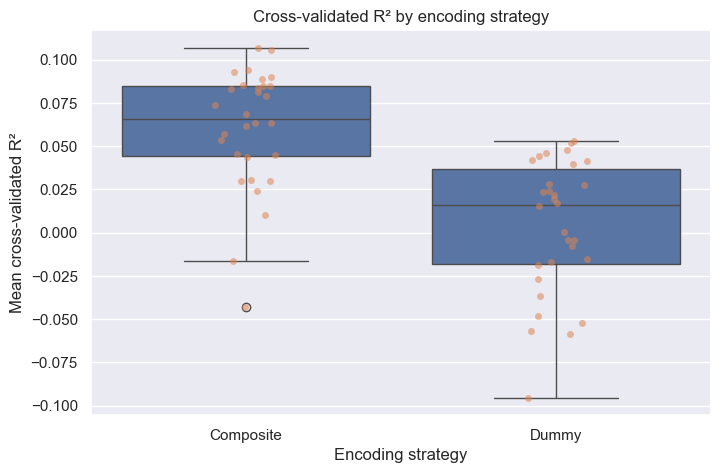

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=repeat_results_long,
    x="strategy",
    y="r2",
)

sns.stripplot(
    data=repeat_results_long,
    x="strategy",
    y="r2",
    alpha=0.55,
)

plt.xlabel("Encoding strategy")
plt.ylabel("Mean cross-validated R²")
plt.title("Cross-validated R² by encoding strategy")
plt.show()

## 11. Plot cross-validated RMSE

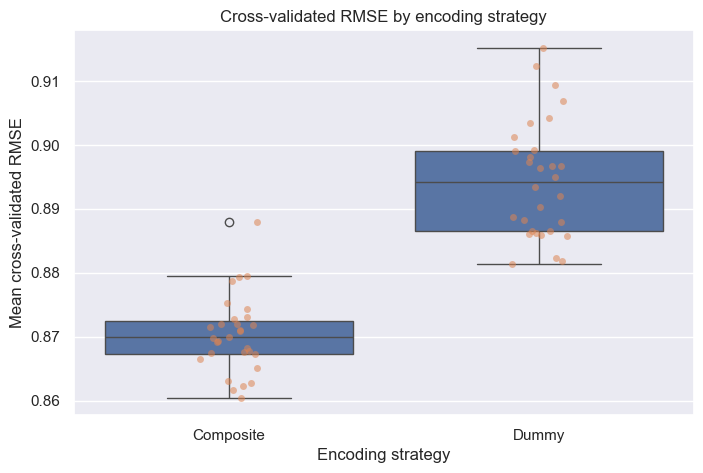

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=repeat_results_long,
    x="strategy",
    y="rmse",
)

sns.stripplot(
    data=repeat_results_long,
    x="strategy",
    y="rmse",
    alpha=0.55,
)

plt.xlabel("Encoding strategy")
plt.ylabel("Mean cross-validated RMSE")
plt.title("Cross-validated RMSE by encoding strategy")
plt.show()

## 12. Save the results

This cell creates CSV tables that can be read into the final Quarto manuscript.

In [13]:
fold_results.to_csv(
    RESULTS_DIR / "encoding_cv_fold_results.csv",
    index=False,
)

repeat_results.to_csv(
    RESULTS_DIR / "encoding_cv_repeat_results.csv",
    index=False,
)

summary.to_csv(
    RESULTS_DIR / "encoding_model_summary.csv",
    index=False,
)

difference_summary.to_csv(
    RESULTS_DIR / "encoding_difference_summary.csv",
    index=False,
)

print(f"Results saved in: {RESULTS_DIR.resolve()}")

Results saved in: /Users/jakevanvleet/Projects/groupproject/data/results


## 13. Interpret the result

In [14]:
mean_r2_difference = repeat_results["r2_difference"].mean()
mean_rmse_difference = repeat_results["rmse_difference"].mean()
mean_mae_difference = repeat_results["mae_difference"].mean()

if mean_r2_difference > 0:
    preferred = "Composite"
else:
    preferred = "Dummy"

print(f"Preferred strategy based on mean cross-validated R²: {preferred}")
print(f"Mean R² difference: {mean_r2_difference:.4f}")
print(f"Mean RMSE difference: {mean_rmse_difference:.4f}")
print(f"Mean MAE difference: {mean_mae_difference:.4f}")

print(
    "\nInterpret this conclusion only for this dataset and prediction "
    "question. It does not establish that one encoding method is always "
    "better in every research setting."
)

Preferred strategy based on mean cross-validated R²: Composite
Mean R² difference: 0.0566
Mean RMSE difference: -0.0242
Mean MAE difference: -0.0092

Interpret this conclusion only for this dataset and prediction question. It does not establish that one encoding method is always better in every research setting.
